In [ ]:
# moex_utils лежит в корне проекта
import sys
sys.path.insert(0, '..')

# Пример работы с данными Мосбиржи 

## Получение списка акций из индекса Мосбиржи

In [1]:
import moex_utils as moex
import pandas as pd
file = 'metadata/stock-index-base.xlsx'

In [2]:
xls = pd.ExcelFile(file)
sheets = xls.sheet_names

In [3]:
# Пытаемся преобразовать каждый элемент в дату
date_sheets = []
for s in sheets:
    try:
        dt = pd.to_datetime(s, format="%d.%m.%Y", errors="raise")
        date_sheets.append(s)
    except Exception:
        pass  # если не дата, пропускаем

print(date_sheets)

['19.12.2025', '19.09.2025', '20.06.2025', '21.03.2025', '20.12.2024', '03.12.2024', '25.11.2024', '14.10.2024', '20.09.2024', '21.06.2024', '22.03.2024', '27.02.2024', '22.12.2023', '22.09.2023', '16.06.2023', '17.03.2023', '16.12.2022', '16.09.2022', '30.06.2022', '17.06.2022', '17.12.2021', '17.09.2021', '18.06.2021', '19.03.2021', '18.12.2020', '18.09.2020', '19.06.2020', '20.03.2020', '20.12.2019', '20.09.2019', '21.06.2019', '22.03.2019', '21.12.2018', '21.09.2018', '22.06.2018', '16.03.2018', '22.12.2017', '22.09.2017', '16.06.2017', '17.03.2017', '16.12.2016', '16.09.2016', '16.06.2016', '16.03.2016', '16.12.2015', '16.09.2015', '16.06.2015', '17.03.2015', '20.01.2015', '16.12.2014', '16.09.2014', '17.06.2014', '18.03.2014', '17.12.2013', '17.09.2013', '18.06.2013', '18.03.2013', '18.12.2012']


In [4]:
# читаем все листы в один DataFrame
all_data = []
for sheet in date_sheets:
    df = pd.read_excel(file, sheet_name=sheet, skiprows=3)
    df["date"] = pd.to_datetime(sheet, format="%d.%m.%Y")  # колонка с датой
    all_data.append(df)

moex_all = pd.concat(all_data, ignore_index=True)

In [5]:
moex_all

,№,Code,Security name (rus),Security name (eng),Number of issued shares,Free-float factor,Restricting coefficient,Weight (28.11.2025),date,Weight (29.08.2025),...,Weight (29.08.2014),Weight (30.05.2014),Weight (28.02.2014),Weight (29.11.2013),Weight (30.08.2013),Weight (31.03.2013),Data Source,Unnamed: 9,Weight (28.02.2013),Weight (30.11.2012)
0,1.0,LKOH,"ПАО ""ЛУКОЙЛ"", ао","PJSC ""LUKOIL"", Ordinary shares",6.928658e+08,0.55,0.497290,0.150000,2025-12-19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,SBER,"ПАО Сбербанк, ао","PJSC ""Sberbank"", Ordinary shares",2.158695e+10,0.48,0.278673,0.126034,2025-12-19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,GAZP,"ПАО ""Газпром"", ао","PJSC ""GAZPROM"", Ordinary shares",2.367351e+10,0.47,0.500000,0.101761,2025-12-19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,YDEX,"МКПАО ""ЯНДЕКС"", ао","IPJSC YANDEX, Ordinary shares",3.932809e+08,0.30,1.000000,0.070675,2025-12-19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,TATN,"ПАО ""Татнефть"" им. В.Д. Шашина, ао","PJSC ""TATNEFT"", Ordinary shares",2.178691e+09,0.32,0.800000,0.047966,2025-12-19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3007,NaN,SVAV,"ОАО СОЛЛЕРС, ао","Sollers, Common",NaN,NaN,NaN,NaN,2012-12-18,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-12-18,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3009,NaN,Исключены / Excluded:,NaN,NaN,NaN,NaN,NaN,NaN,2012-12-18,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3010,NaN,BSPB,"ОАО Банк Санкт-Петербург, ао","OJSC ""Bank ""Saint-Petersburg"", Common",NaN,NaN,NaN,NaN,2012-12-18,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import re
import numpy as np

unique_codes  = moex_all["Code"].unique()
# убираем NaN
codes = [c for c in unique_codes if isinstance(c, str)]

# оставляем только тикеры: заглавные латиницей, без пробелов и спецсимволов
ticker_pattern = re.compile(r'^[A-Z]{1,6}$')

tickers = [c for c in codes if ticker_pattern.match(c)]

print(sorted(tickers))

['AFKS', 'AFLT', 'AGRO', 'AKRN', 'ALRS', 'ASTR', 'BANE', 'BANEP', 'BSPB', 'CBOM', 'CHMF', 'CNRU', 'DIXY', 'DOMRF', 'DSKY', 'ENPG', 'EONR', 'EPLN', 'FEES', 'FIVE', 'FIXP', 'FLOT', 'GAZP', 'GCHE', 'GLTR', 'GMKN', 'HEAD', 'HHRU', 'HYDR', 'IRAO', 'KMAZ', 'LEAS', 'LKOH', 'LNTA', 'LSRG', 'MAGN', 'MAIL', 'MDMG', 'MFON', 'MGNT', 'MOEX', 'MRKH', 'MSNG', 'MSRS', 'MSTT', 'MTLR', 'MTLRP', 'MTSS', 'MVID', 'NKNC', 'NLMK', 'NMTP', 'NVTK', 'OGKB', 'OZON', 'PGIL', 'PHOR', 'PHST', 'PIKK', 'PLZL', 'POGR', 'POLY', 'POSI', 'QIWI', 'RASP', 'RENI', 'RNFT', 'ROSN', 'RSTI', 'RTKM', 'RTKMP', 'RUAL', 'RUALR', 'SBER', 'SBERP', 'SELG', 'SFIN', 'SGZH', 'SMLT', 'SNGS', 'SNGSP', 'SVAV', 'SVCB', 'T', 'TATN', 'TATNP', 'TCSG', 'TNBPP', 'TRMK', 'TRNFP', 'UGLD', 'UPRO', 'URKA', 'UWGN', 'VKCO', 'VSMO', 'VTBR', 'VZRZ', 'YDEX', 'YNDX']


In [8]:
len(tickers)

100

In [9]:
import moex_utils as moex
import pyarrow

In [10]:
start = '1990-01-01'
end = '2027-01-01'


In [11]:
for ticker in tickers:
    print(f"Saving data for ticker: {ticker}")
    moex.save_moex_stock(ticker, start, end)

Saving data for ticker: LKOH
[INFO] LKOH: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] LKOH: market cap рассчитан
[OK] LKOH: 5,665 rows → data\LKOH\LKOH.parquet
Saving data for ticker: SBER
[INFO] SBER: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] SBER: market cap рассчитан
[OK] SBER: 4,693 rows → data\SBER\SBER.parquet
Saving data for ticker: GAZP
[INFO] GAZP: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] GAZP: market cap рассчитан
[OK] GAZP: 5,065 rows → data\GAZP\GAZP.parquet
Saving data for ticker: YDEX
[INFO] YDEX: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] YDEX: market cap рассчитан
[OK] YDEX: 433 rows → data\YDEX\YDEX.parquet
Saving data for ticker: TATN
[INFO] TATN: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] TATN: market cap рассчитан
[OK] TATN: 6,083 rows → data\TATN\TATN.parquet
Saving data for ticker: T
[INFO] T: fetching 1990-01-01 → 2027-01-01, freq=24
[INFO] T: market cap рассчитан
[OK] T: 1,592 rows → data\T\T.parquet
Saving data for ticker: NVTK
[

In [ ]:
for ticker in tickers:
    print(f"Saving data for ticker: {ticker}")
    moex.update_moex_stock(ticker)

Updated data for ticker: TNBPP from 2013-10-25 to 2026-01-04


In [12]:
ticker = 'TRNFP'

In [13]:
df = moex.read_moex_stock(ticker)
df

Loaded data for ticker: TRNFP from local file.


,open,close,high,low,value_rub,volume,ticker,shares,market_cap
date,,,,,,,,,
2008-01-14,492.0000,488.0000,492.0000,486.0500,2.320658e+08,4754.0,TRNFP,1554875.0,7.587790e+08
2008-01-15,487.0101,487.5974,489.0000,483.5662,2.101499e+08,4320.0,TRNFP,1554875.0,7.581530e+08
2008-01-16,479.0100,477.0001,484.9800,473.7501,4.521549e+08,9461.0,TRNFP,1554875.0,7.416755e+08
2008-01-17,483.3499,463.0000,483.3499,450.3000,2.667155e+08,5736.0,TRNFP,1554875.0,7.199071e+08
2008-01-18,461.5000,469.8000,472.0000,452.2105,1.593009e+08,3438.0,TRNFP,1554875.0,7.304803e+08
...,...,...,...,...,...,...,...,...,...
2025-12-30,1377.2000,1378.0000,1384.8000,1367.4000,4.761307e+08,345539.0,TRNFP,155487500.0,2.142618e+11
2026-01-05,1378.4000,1394.0000,1400.4000,1368.0000,4.009126e+08,288983.0,TRNFP,155487500.0,2.167496e+11
2026-01-06,1394.0000,1409.8000,1421.8000,1394.0000,4.875236e+08,345312.0,TRNFP,155487500.0,2.192063e+11


In [ ]:
# Добавление adjusted close 

In [14]:
div_folder = 'G:/YandexDisk/FINANCE/dividends/data/'
moex.add_adj_close_to_all_stocks(div_folder)

Found 100 stocks to process for adjusted close calculation.
Processing AFKS...
Successfully updated AFKS with adj_close column.
Processing AFLT...
Successfully updated AFLT with adj_close column.
Processing AGRO...
Successfully updated AGRO with adj_close column.
Processing AKRN...
Successfully updated AKRN with adj_close column.
Processing ALRS...
Successfully updated ALRS with adj_close column.
Processing ASTR...
Info: No dividend file found for ASTR at G:/YandexDisk/FINANCE/dividends/data/ASTR.csv. Setting adj_close equal to close.
Successfully updated ASTR with adj_close column.
Processing BANE...
Successfully updated BANE with adj_close column.
Processing BANEP...
Successfully updated BANEP with adj_close column.
Processing BSPB...
Successfully updated BSPB with adj_close column.
Processing CBOM...
Successfully updated CBOM with adj_close column.
Processing CHMF...
Successfully updated CHMF with adj_close column.
Processing CNRU...
Info: No dividend file found for CNRU at G:/Yande

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

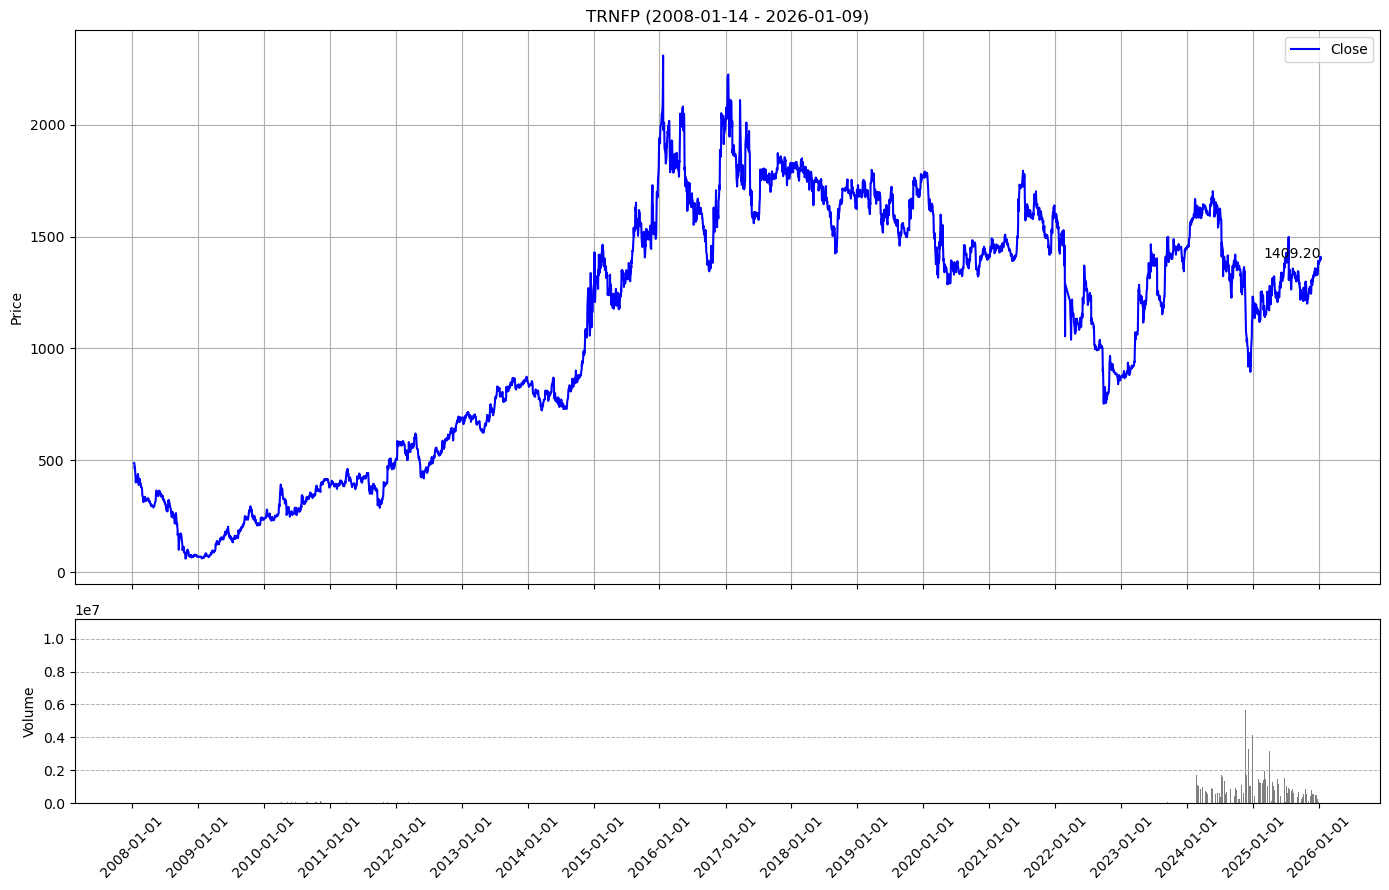

In [17]:
 # Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Candlestick representation (high-low line)
ax1.plot(df.index, df['close'], label='Close', color='blue')
ax1.set_ylabel('Price')
start_date = df.index.min().strftime('%Y-%m-%d')
end_date = df.index.max().strftime('%Y-%m-%d')
ax1.set_title(f"{ticker} ({start_date} - {end_date})")
ax1.text(df.index[-1], df['close'].iloc[-1] - 20, f'{df["close"].iloc[-1]:.2f}', 
         fontsize=10, color='black', ha='right', va='bottom')
ax1.legend()
ax1.grid()

# Volume bar plot
ax2.bar(df.index, df['volume'], width=0.8, color='gray')
ax2.set_ylabel('Volume')
ax2.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Formatting date on x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Собрать все данные в один датасет 

In [18]:
# Combine all stock data
combined_stocks = moex.combine_moex_stocks()

# Display basic information about the combined dataset
print("\nDataset Info:")
print(combined_stocks.info())

# Show first few rows
print("\nFirst few rows:")
print(combined_stocks.head())

# Basic statistics
print("\nBasic statistics:")
print(combined_stocks.describe())

Loaded data for AFKS
Loaded data for AFLT
Loaded data for AGRO
Loaded data for AKRN
Loaded data for ALRS
Loaded data for ASTR
Loaded data for BANE
Loaded data for BANEP
Loaded data for BSPB
Loaded data for CBOM
Loaded data for CHMF
Loaded data for CNRU
Loaded data for DIXY
Loaded data for DOMRF
Loaded data for DSKY
Loaded data for ENPG
Loaded data for EONR
Loaded data for EPLN
Loaded data for FEES
Loaded data for FIVE
Loaded data for FIXP
Loaded data for FLOT
Loaded data for GAZP
Loaded data for GCHE
Loaded data for GLTR
Loaded data for GMKN
Loaded data for HEAD
Loaded data for HHRU
Loaded data for HYDR
Loaded data for IRAO
Loaded data for KMAZ
Loaded data for LEAS
Loaded data for LKOH
Loaded data for LNTA
Loaded data for LSRG
Loaded data for MAGN
Loaded data for MAIL
Loaded data for MDMG
Loaded data for MFON
Loaded data for MGNT
Loaded data for MOEX
Loaded data for MRKH
Loaded data for MSNG
Loaded data for MSRS
Loaded data for MSTT
Loaded data for MTLR
Loaded data for MTLRP
Loaded dat

In [19]:
combined_stocks

,open,close,high,low,value_rub,volume,ticker
date,,,,,,,
2007-12-12,43.000,41.449,43.00,41.000,1.922004e+07,465200.0,AFKS
2007-12-13,41.200,40.896,41.20,40.000,2.383380e+07,585400.0,AFKS
2007-12-14,40.985,41.797,42.35,40.000,5.323530e+07,1284700.0,AFKS
2007-12-17,41.890,41.900,43.00,41.101,5.369148e+07,1276500.0,AFKS
2007-12-18,41.001,41.400,42.89,41.000,3.428903e+07,817900.0,AFKS
...,...,...,...,...,...,...,...
2024-06-07,4229.000,4222.000,4284.20,4210.600,1.398056e+09,329137.0,YNDX
2024-06-10,4222.000,4125.600,4248.00,4082.800,1.242645e+09,297380.0,YNDX
2024-06-11,4100.600,4102.000,4140.60,4092.000,9.600398e+08,233821.0,YNDX


In [10]:
def plot_stocks_performance():
    """
    Calculates last month's performance for each stock and creates a horizontal bar chart.
    Performance is calculated as percentage change between the last prices of the first and last days.
    """
    import matplotlib.pyplot as plt
    
    # Get combined dataset
    combined_df = moex.combine_moex_stocks()
    
    # Get current date and date 1 month ago
    end_date = pd.Timestamp.now()
    start_date = end_date - pd.DateOffset(months=12)
    
    # Calculate performance for each stock
    performances = []
    
    for ticker in combined_df['ticker'].unique():
        # Get data for specific ticker
        stock_data = combined_df[combined_df['ticker'] == ticker]
        
        # Filter for last month and sort by date
        mask = (stock_data.index >= start_date) & (stock_data.index <= end_date)
        monthly_data = stock_data[mask].sort_index()
        
        if len(monthly_data) >= 2:  # Check if we have at least 2 data points
            # Get first and last day prices
            first_day = monthly_data.index.min()
            last_day = monthly_data.index.max()
            
            first_price = monthly_data.loc[first_day, 'close']
            last_price = monthly_data.loc[last_day, 'close']
            
            # Calculate performance
            performance = ((last_price - first_price) / first_price) * 100
            performances.append({
                'ticker': ticker,
                'performance': performance,
                'first_price': first_price,
                'last_price': last_price,
                'start_date': first_day,
                'end_date': last_day
            })
    
    # Create DataFrame with performances and sort
    perf_df = pd.DataFrame(performances)
    perf_df = perf_df.sort_values('performance', ascending=True)
    
    # Create horizontal bar chart
    plt.figure(figsize=(12, max(8, len(perf_df) * 0.3)))  # Adjust height based on number of stocks
    
    # Create horizontal bars
    bars = plt.barh(perf_df['ticker'], perf_df['performance'])
    
    # Customize the chart
    plt.title('Last Month Stock Performance (%)', pad=20)
    plt.xlabel('Performance (%)')
    plt.ylabel('Ticker')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add value labels on the bars
    for bar in bars:
        width = bar.get_width()
        x_pos = width if width >= 0 else width
        plt.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                ha='left' if width >= 0 else 'right', 
                va='center',
                fontweight='bold')
    
    # Color bars based on performance
    for bar in bars:
        if bar.get_width() >= 0:
            bar.set_color('green')
        else:
            bar.set_color('red')
    
    # Add zero line
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Print detailed performance data
    print("\nPerformance Summary:")
    summary_df = perf_df[['ticker', 'performance', 'first_price', 'last_price', 'start_date', 'end_date']]
    print(summary_df.sort_values('performance', ascending=False).to_string())
    
    return perf_df

# Usage
performance_data = plot_stocks_performance()

Loaded data for AFKS
Loaded data for AFLT
Loaded data for AGRO
Loaded data for AKRN
Loaded data for ALRS
Loaded data for ASTR
Loaded data for BANE
Loaded data for BANEP
Loaded data for BSPB
Loaded data for CBOM
Loaded data for CHMF
Loaded data for CNRU
Loaded data for DIXY
Loaded data for DOMRF
Loaded data for DSKY
Loaded data for ENPG
Loaded data for EONR
Loaded data for EPLN
Loaded data for FEES
Loaded data for FIVE
Loaded data for FIXP
Loaded data for FLOT
Loaded data for GAZP
Loaded data for GCHE
Loaded data for GLTR
Loaded data for GMKN
Loaded data for HEAD
Loaded data for HHRU
Loaded data for HYDR
Loaded data for IRAO
Loaded data for KMAZ
Loaded data for LEAS
Loaded data for LKOH
Loaded data for LNTA
Loaded data for LSRG
Loaded data for MAGN
Loaded data for MAIL
Loaded data for MDMG
Loaded data for MFON
Loaded data for MGNT
Loaded data for MOEX
Loaded data for MRKH
Loaded data for MSNG
Loaded data for MSRS
Loaded data for MSTT
Loaded data for MTLR
Loaded data for MTLRP
Loaded dat

NameError: name 'pd' is not defined